In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Data Loading and Initial Exploration

In [4]:
fear_greed = pd.read_csv('csv_files/fear_greed_index.csv')
trading_data = pd.read_csv('csv_files/historical_data.csv')

In [6]:
print("Fear & Greed Index Dataset Shape:", fear_greed.shape)
print("Trading Data Dataset Shape:", trading_data.shape)

Fear & Greed Index Dataset Shape: (2644, 4)
Trading Data Dataset Shape: (211224, 16)


In [7]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trading_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
print(fear_greed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [10]:
print(fear_greed.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [11]:
display(fear_greed.describe())

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [12]:
print(trading_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [13]:
print(trading_data.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [14]:
display(trading_data.describe())

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


## 2. Data Preprocessing and Cleaning

In [15]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [16]:
fear_greed = fear_greed.sort_values('date')

In [17]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [19]:
print(fear_greed['classification'].value_counts())

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [21]:
trading_data['Timestamp'].iloc[0]

1730000000000.0

In [23]:
trading_data['Timestamp'] = pd.to_datetime(trading_data['Timestamp'], unit='ms')
trading_data['Date'] = trading_data['Timestamp'].dt.date
trading_data['Date'] = pd.to_datetime(trading_data['Date'])

## 3. Merging Datasets on Date

In [24]:
merged_data = trading_data.merge(
    fear_greed[['date', 'value', 'classification']], 
    left_on='Date', 
    right_on='date', 
    how='left'
)

In [25]:
merged_data = merged_data.rename(columns={
    'value': 'sentiment_value',
    'classification': 'sentiment'
})

In [26]:
merged_data = merged_data.drop('date', axis=1)

In [27]:
print(f"Merged Dataset Shape: {merged_data.shape}")
print(f"\nRecords with Sentiment Data: {merged_data['sentiment'].notna().sum()}")
print(f"Records without Sentiment Data: {merged_data['sentiment'].isna().sum()}")

Merged Dataset Shape: (211224, 19)

Records with Sentiment Data: 184263
Records without Sentiment Data: 26961


In [29]:
merged_data = merged_data.dropna(subset=['sentiment'])
print(f"Final Merged Dataset Shape after removing athe nulls : {merged_data.shape}")

Final Merged Dataset Shape after removing athe nulls : (184263, 19)


In [31]:
merged_data.head(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,sentiment_value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,02-12-2024 22:50,1298.215466,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.000493,7.330000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,02-12-2024 22:50,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,9.060000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,02-12-2024 22:50,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.011900,3.960000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,02-12-2024 22:50,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.016100,9.460000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,02-12-2024 22:50,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.004375,3.470000e+13,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [32]:
merged_data.to_csv('csv_files/merged_trading_sentiment.csv', index=False)

## 4. Exploratory Data Analysis (EDA)

### 4.1 Market Sentiment Distribution Over Time

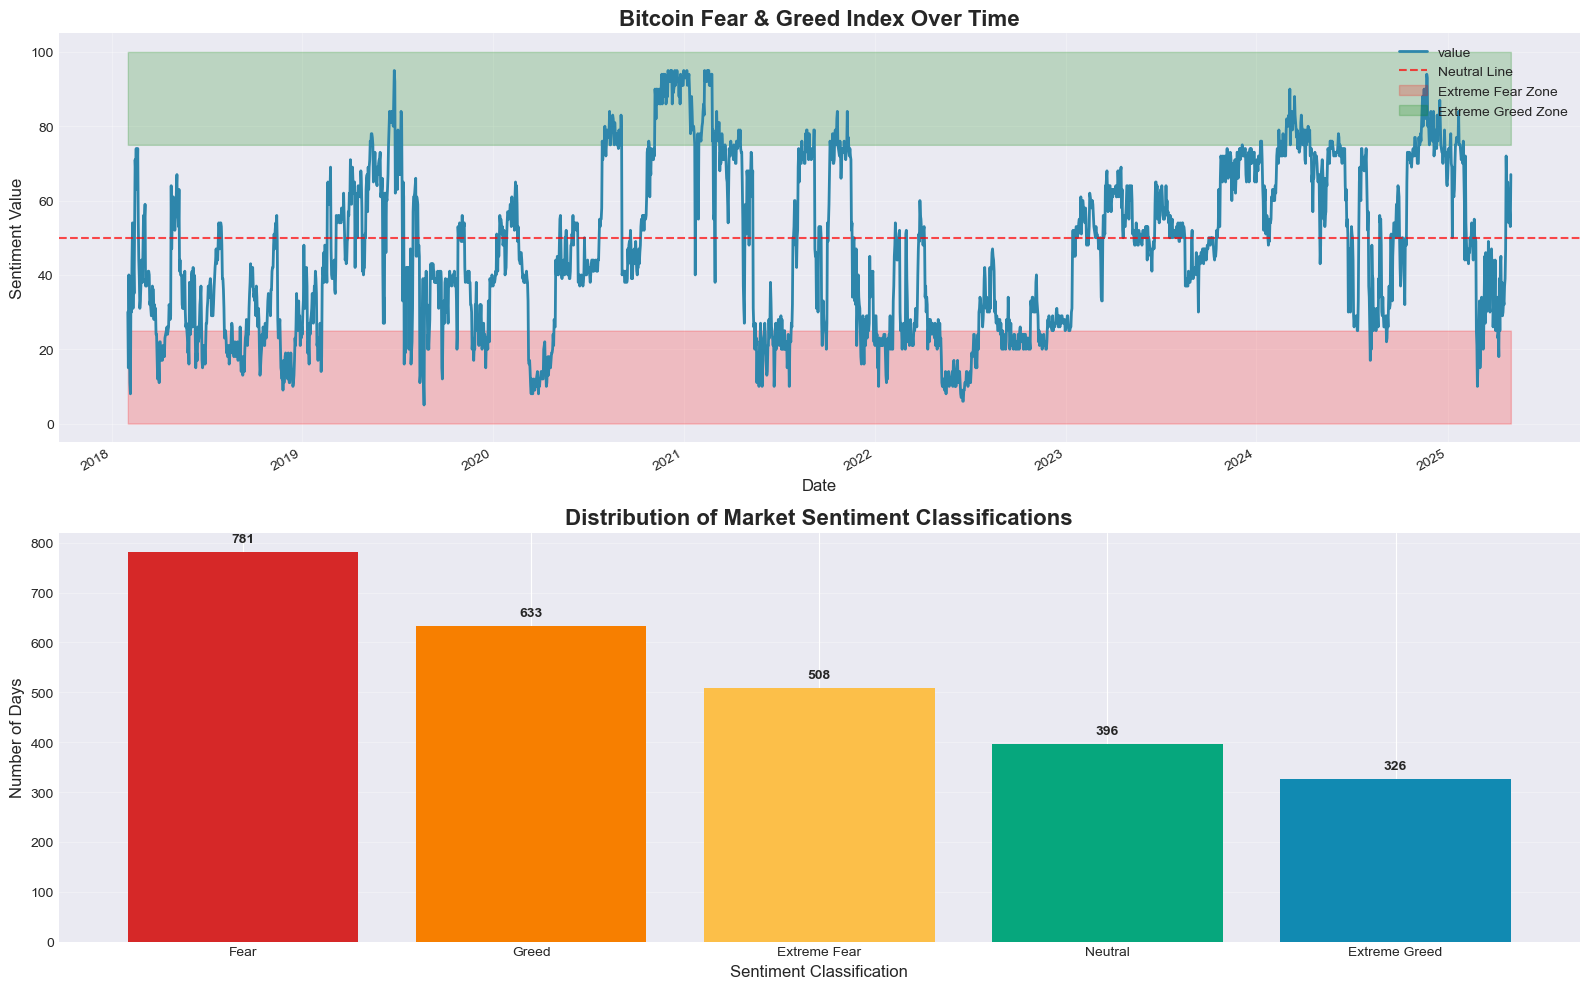

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

fear_greed.set_index('date')['value'].plot(ax=axes[0], linewidth=2, color='#2E86AB')
axes[0].axhline(y=50, color='red', linestyle='--', label='Neutral Line', alpha=0.7)
axes[0].fill_between(fear_greed['date'], 0, 25, alpha=0.2, color='red', label='Extreme Fear Zone')
axes[0].fill_between(fear_greed['date'], 75, 100, alpha=0.2, color='green', label='Extreme Greed Zone')
axes[0].set_title('Bitcoin Fear & Greed Index Over Time', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Sentiment Value', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

sentiment_counts = fear_greed['classification'].value_counts()
colors = ['#D62828', '#F77F00', '#FCBF49', '#06A77D', '#118AB2']
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors[:len(sentiment_counts)])
axes[1].set_title('Distribution of Market Sentiment Classifications', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Number of Days', fontsize=12)
axes[1].set_xlabel('Sentiment Classification', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Trading Volume Analysis by Sentiment

In [36]:
volume_by_sentiment = merged_data.groupby('sentiment').agg({
    'Size USD': ['sum', 'mean', 'median', 'count'],
    'Size Tokens': ['sum', 'mean']
}).round(2)

In [38]:
volume_by_sentiment

Size USD                             Size Tokens          
                        sum     mean   median   count           sum      mean
sentiment                                                                    
Extreme Greed  3.940677e+07  5660.27  1148.64    6962  3.393031e+08  48736.44
Fear           7.041585e+08  5259.98   605.07  133871  4.111879e+08   3071.52
Greed          1.155037e+08  3182.88   499.94   36289  8.100132e+07   2232.12
Neutral        2.184323e+07  3058.85   554.16    7141  1.404851e+07   1967.30

In [39]:
volume_by_sentiment.to_csv('csv_files/volume_by_sentiment.csv')

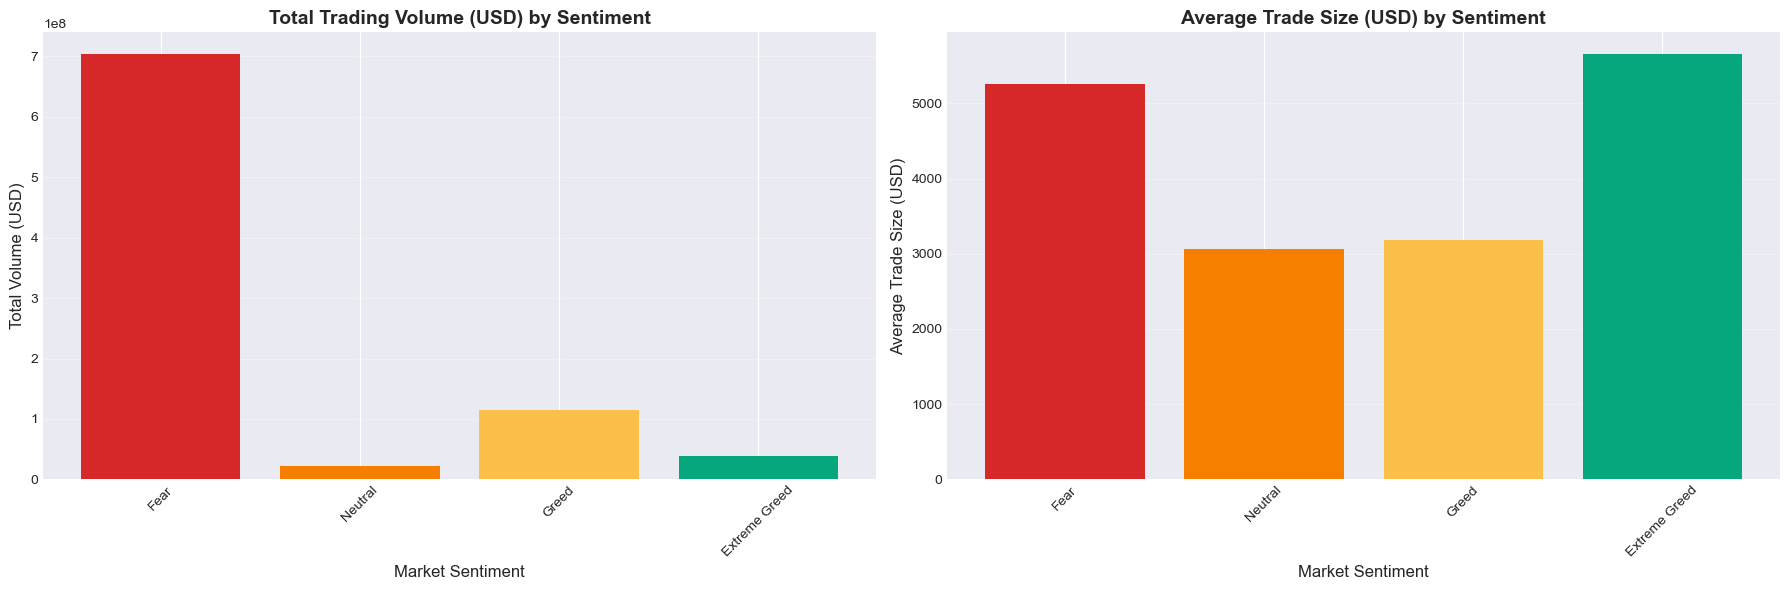

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_order = [s for s in sentiment_order if s in merged_data['sentiment'].unique()]

total_volume = merged_data.groupby('sentiment')['Size USD'].sum().reindex(sentiment_order)
axes[0].bar(total_volume.index, total_volume.values, color=['#D62828', '#F77F00', '#FCBF49', '#06A77D', '#118AB2'][:len(total_volume)])
axes[0].set_title('Total Trading Volume (USD) by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Volume (USD)', fontsize=12)
axes[0].set_xlabel('Market Sentiment', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

avg_trade_size = merged_data.groupby('sentiment')['Size USD'].mean().reindex(sentiment_order)
axes[1].bar(avg_trade_size.index, avg_trade_size.values, color=['#D62828', '#F77F00', '#FCBF49', '#06A77D', '#118AB2'][:len(avg_trade_size)])
axes[1].set_title('Average Trade Size (USD) by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Trade Size (USD)', fontsize=12)
axes[1].set_xlabel('Market Sentiment', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/volume_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Profitability Analysis (Closed PnL)

In [42]:
merged_data['Closed PnL'] = pd.to_numeric(merged_data['Closed PnL'], errors='coerce')

In [43]:
pnl_trades = merged_data[merged_data['Closed PnL'] != 0].copy()

In [44]:
pnl_by_sentiment = pnl_trades.groupby('sentiment')['Closed PnL'].agg([
    'sum', 'mean', 'median', 'std', 'count'
]).round(2)

In [45]:
pnl_by_sentiment['profit_ratio'] = (pnl_trades.groupby('sentiment')['Closed PnL'].apply(
    lambda x: (x > 0).sum() / len(x) * 100
)).round(2)

In [46]:
pnl_by_sentiment

,sum,mean,median,std,count,profit_ratio
sentiment,,,,,,
Extreme Greed,176965.49,40.85,10.48,387.34,4332,78.76
Fear,6699925.19,103.82,6.84,1307.25,64536,86.12
Greed,3189616.54,167.21,7.39,1579.73,19075,84.94
Neutral,158742.38,56.45,5.11,1009.01,2812,80.55


In [47]:
pnl_by_sentiment.to_csv('csv_files/pnl_by_sentiment.csv')

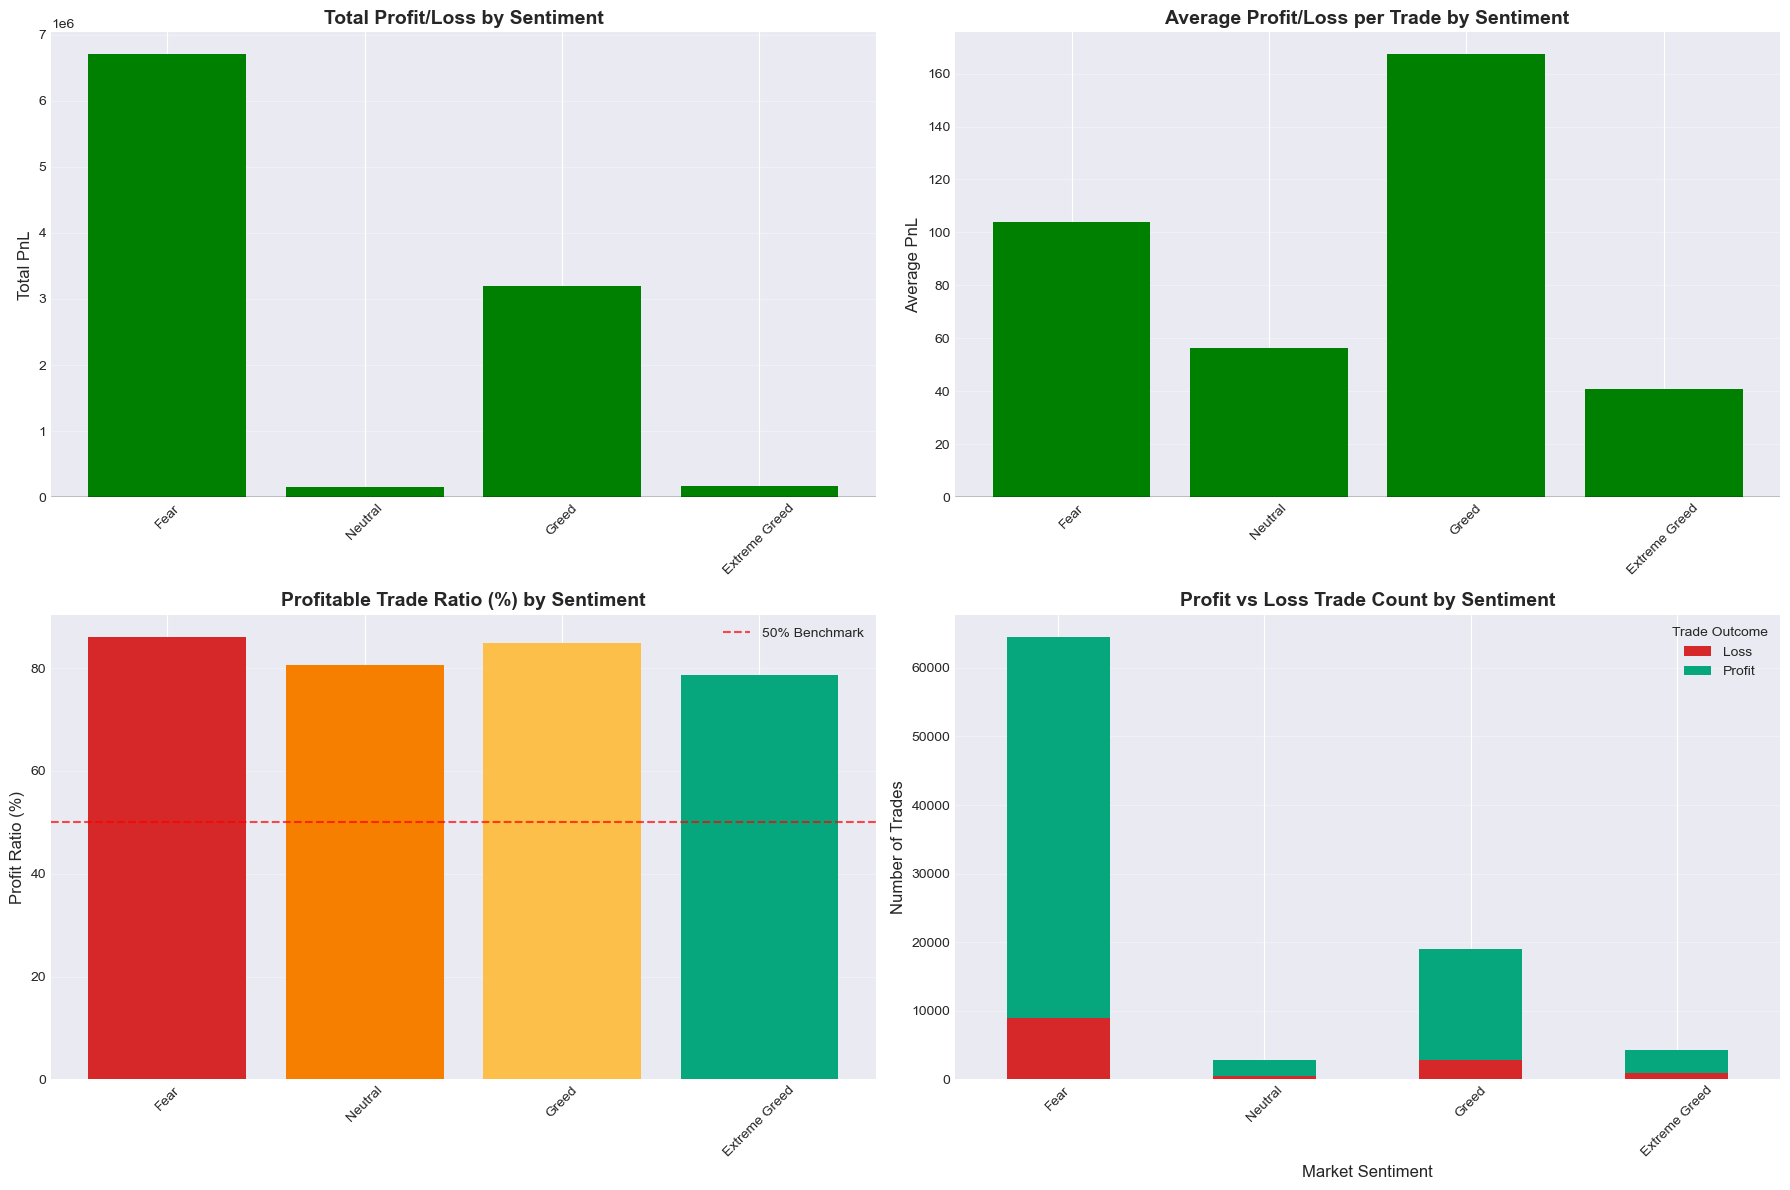

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_order = [s for s in sentiment_order if s in pnl_by_sentiment.index]

total_pnl = pnl_by_sentiment['sum'].reindex(sentiment_order)
colors = ['red' if x < 0 else 'green' for x in total_pnl.values]
axes[0, 0].bar(total_pnl.index, total_pnl.values, color=colors)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0, 0].set_title('Total Profit/Loss by Sentiment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Total PnL', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

avg_pnl = pnl_by_sentiment['mean'].reindex(sentiment_order)
colors = ['red' if x < 0 else 'green' for x in avg_pnl.values]
axes[0, 1].bar(avg_pnl.index, avg_pnl.values, color=colors)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_title('Average Profit/Loss per Trade by Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average PnL', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

profit_ratio = pnl_by_sentiment['profit_ratio'].reindex(sentiment_order)
axes[1, 0].bar(profit_ratio.index, profit_ratio.values, color=['#D62828', '#F77F00', '#FCBF49', '#06A77D', '#118AB2'][:len(profit_ratio)])
axes[1, 0].axhline(y=50, color='red', linestyle='--', label='50% Benchmark', alpha=0.7)
axes[1, 0].set_title('Profitable Trade Ratio (%) by Sentiment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Profit Ratio (%)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

pnl_trades['PnL_Category'] = pnl_trades['Closed PnL'].apply(lambda x: 'Profit' if x > 0 else 'Loss')
pnl_distribution = pnl_trades.groupby(['sentiment', 'PnL_Category']).size().unstack(fill_value=0)
pnl_distribution = pnl_distribution.reindex(sentiment_order)
pnl_distribution.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#D62828', '#06A77D'])
axes[1, 1].set_title('Profit vs Loss Trade Count by Sentiment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Trades', fontsize=12)
axes[1, 1].set_xlabel('Market Sentiment', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Trade Outcome')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/profitability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4 Buy vs Sell Behavior by Sentiment

In [49]:
side_sentiment = merged_data.groupby(['sentiment', 'Side']).agg({
    'Size USD': ['sum', 'count', 'mean']
}).round(2)

In [50]:
side_sentiment

Size USD                
                             sum  count     mean
sentiment     Side                              
Extreme Greed BUY   1.957830e+07   3371  5807.86
              SELL  1.982847e+07   3591  5521.71
Fear          BUY   3.537757e+08  66081  5353.67
              SELL  3.503828e+08  67790  5168.65
Greed         BUY   5.614314e+07  15421  3640.69
              SELL  5.936053e+07  20868  2844.57
Neutral       BUY   1.090471e+07   3505  3111.19
              SELL  1.093852e+07   3636  3008.39

In [51]:
side_sentiment.to_csv('csv_files/side_by_sentiment.csv')

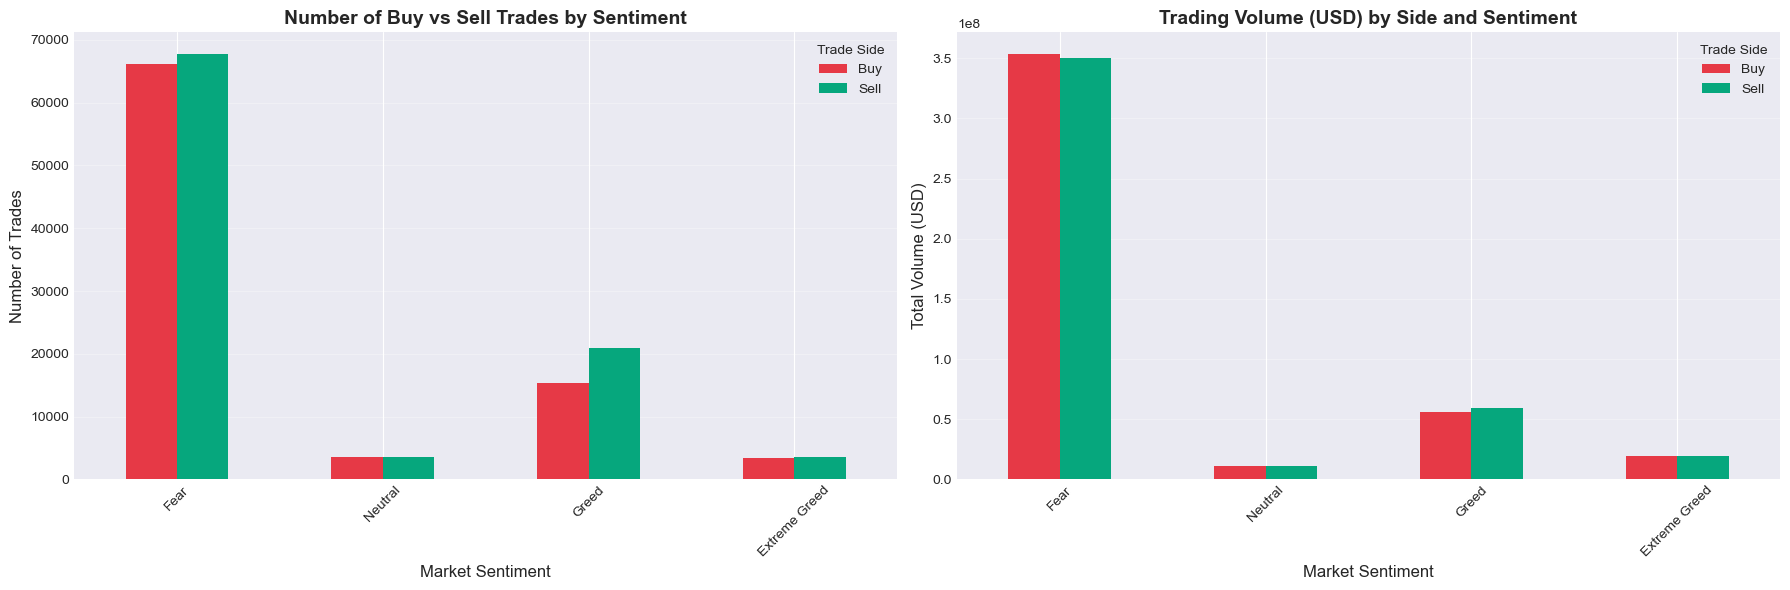

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

side_counts = merged_data.groupby(['sentiment', 'Side']).size().unstack(fill_value=0)
side_counts = side_counts.reindex(sentiment_order)
side_counts.plot(kind='bar', ax=axes[0], color=['#E63946', '#06A77D'])
axes[0].set_title('Number of Buy vs Sell Trades by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Trades', fontsize=12)
axes[0].set_xlabel('Market Sentiment', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Trade Side', labels=['Buy', 'Sell'])
axes[0].grid(axis='y', alpha=0.3)

side_volume = merged_data.groupby(['sentiment', 'Side'])['Size USD'].sum().unstack(fill_value=0)
side_volume = side_volume.reindex(sentiment_order)
side_volume.plot(kind='bar', ax=axes[1], color=['#E63946', '#06A77D'])
axes[1].set_title('Trading Volume (USD) by Side and Sentiment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Volume (USD)', fontsize=12)
axes[1].set_xlabel('Market Sentiment', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Trade Side', labels=['Buy', 'Sell'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/buy_sell_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5 Top Traded Coins by Sentiment

In [53]:
top_coins_overall = merged_data['Coin'].value_counts().head(10)
top_coins_overall

Coin
HYPE         62446
@107         27385
BTC          20135
ETH          10862
SOL           8523
FARTCOIN      3431
MELANIA       3322
PURR/USDC     2769
SUI           1847
XRP           1774
Name: count, dtype: int64

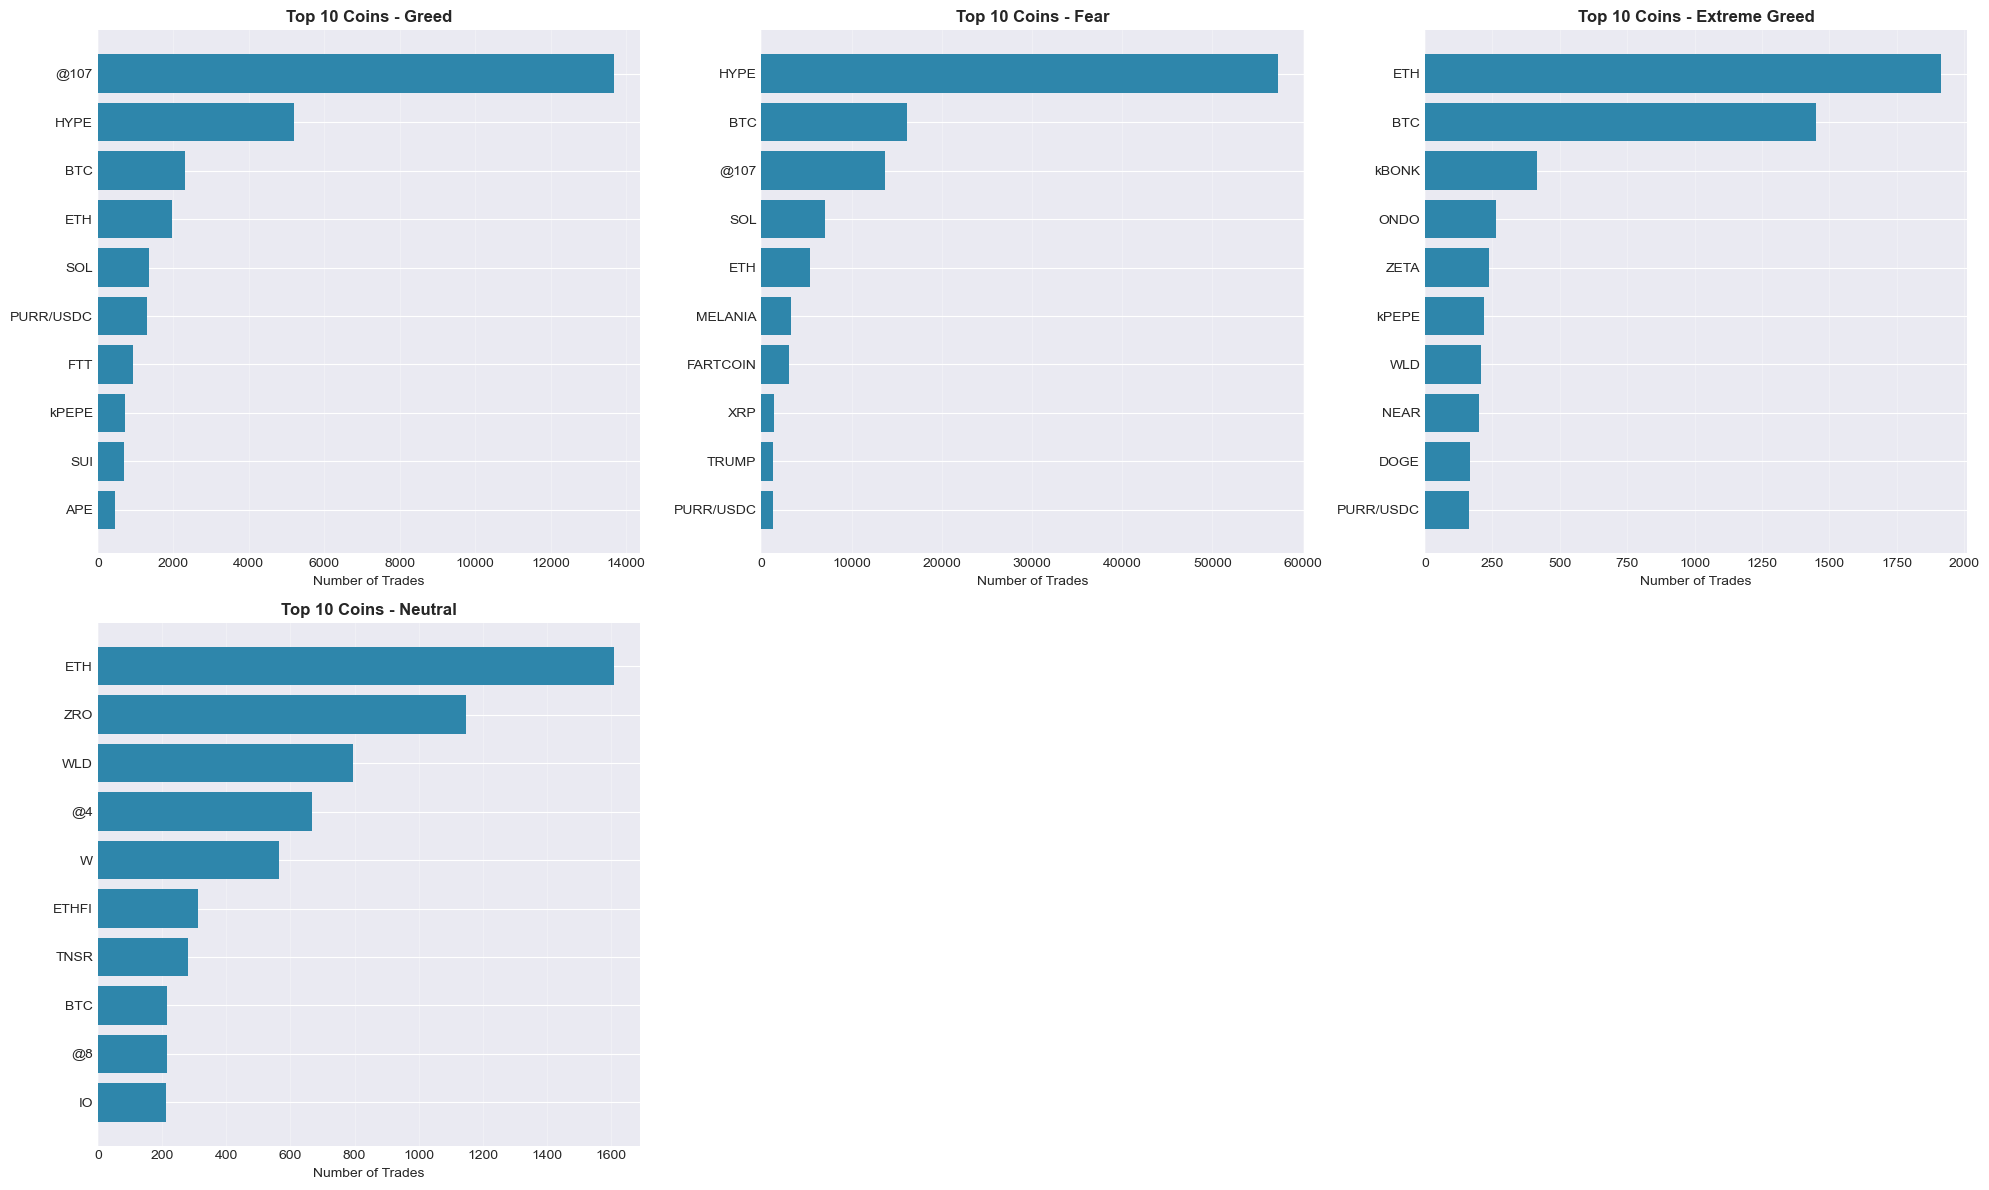

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

sentiments = merged_data['sentiment'].unique()

for idx, sentiment in enumerate(sentiments):
    if idx < len(axes):
        sentiment_data = merged_data[merged_data['sentiment'] == sentiment]
        top_coins = sentiment_data['Coin'].value_counts().head(10)
        
        axes[idx].barh(range(len(top_coins)), top_coins.values, color='#2E86AB')
        axes[idx].set_yticks(range(len(top_coins)))
        axes[idx].set_yticklabels(top_coins.index)
        axes[idx].set_xlabel('Number of Trades', fontsize=10)
        axes[idx].set_title(f'Top 10 Coins - {sentiment}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].invert_yaxis()

for idx in range(len(sentiments), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('outputs/top_coins_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.6 Time-Based Trading Patterns

In [55]:
daily_trades = merged_data.groupby('Date').agg({
    'Size USD': ['sum', 'count'],
    'sentiment_value': 'mean'
}).reset_index()

In [56]:
daily_trades.columns = ['Date', 'Total_Volume', 'Trade_Count', 'Avg_Sentiment']

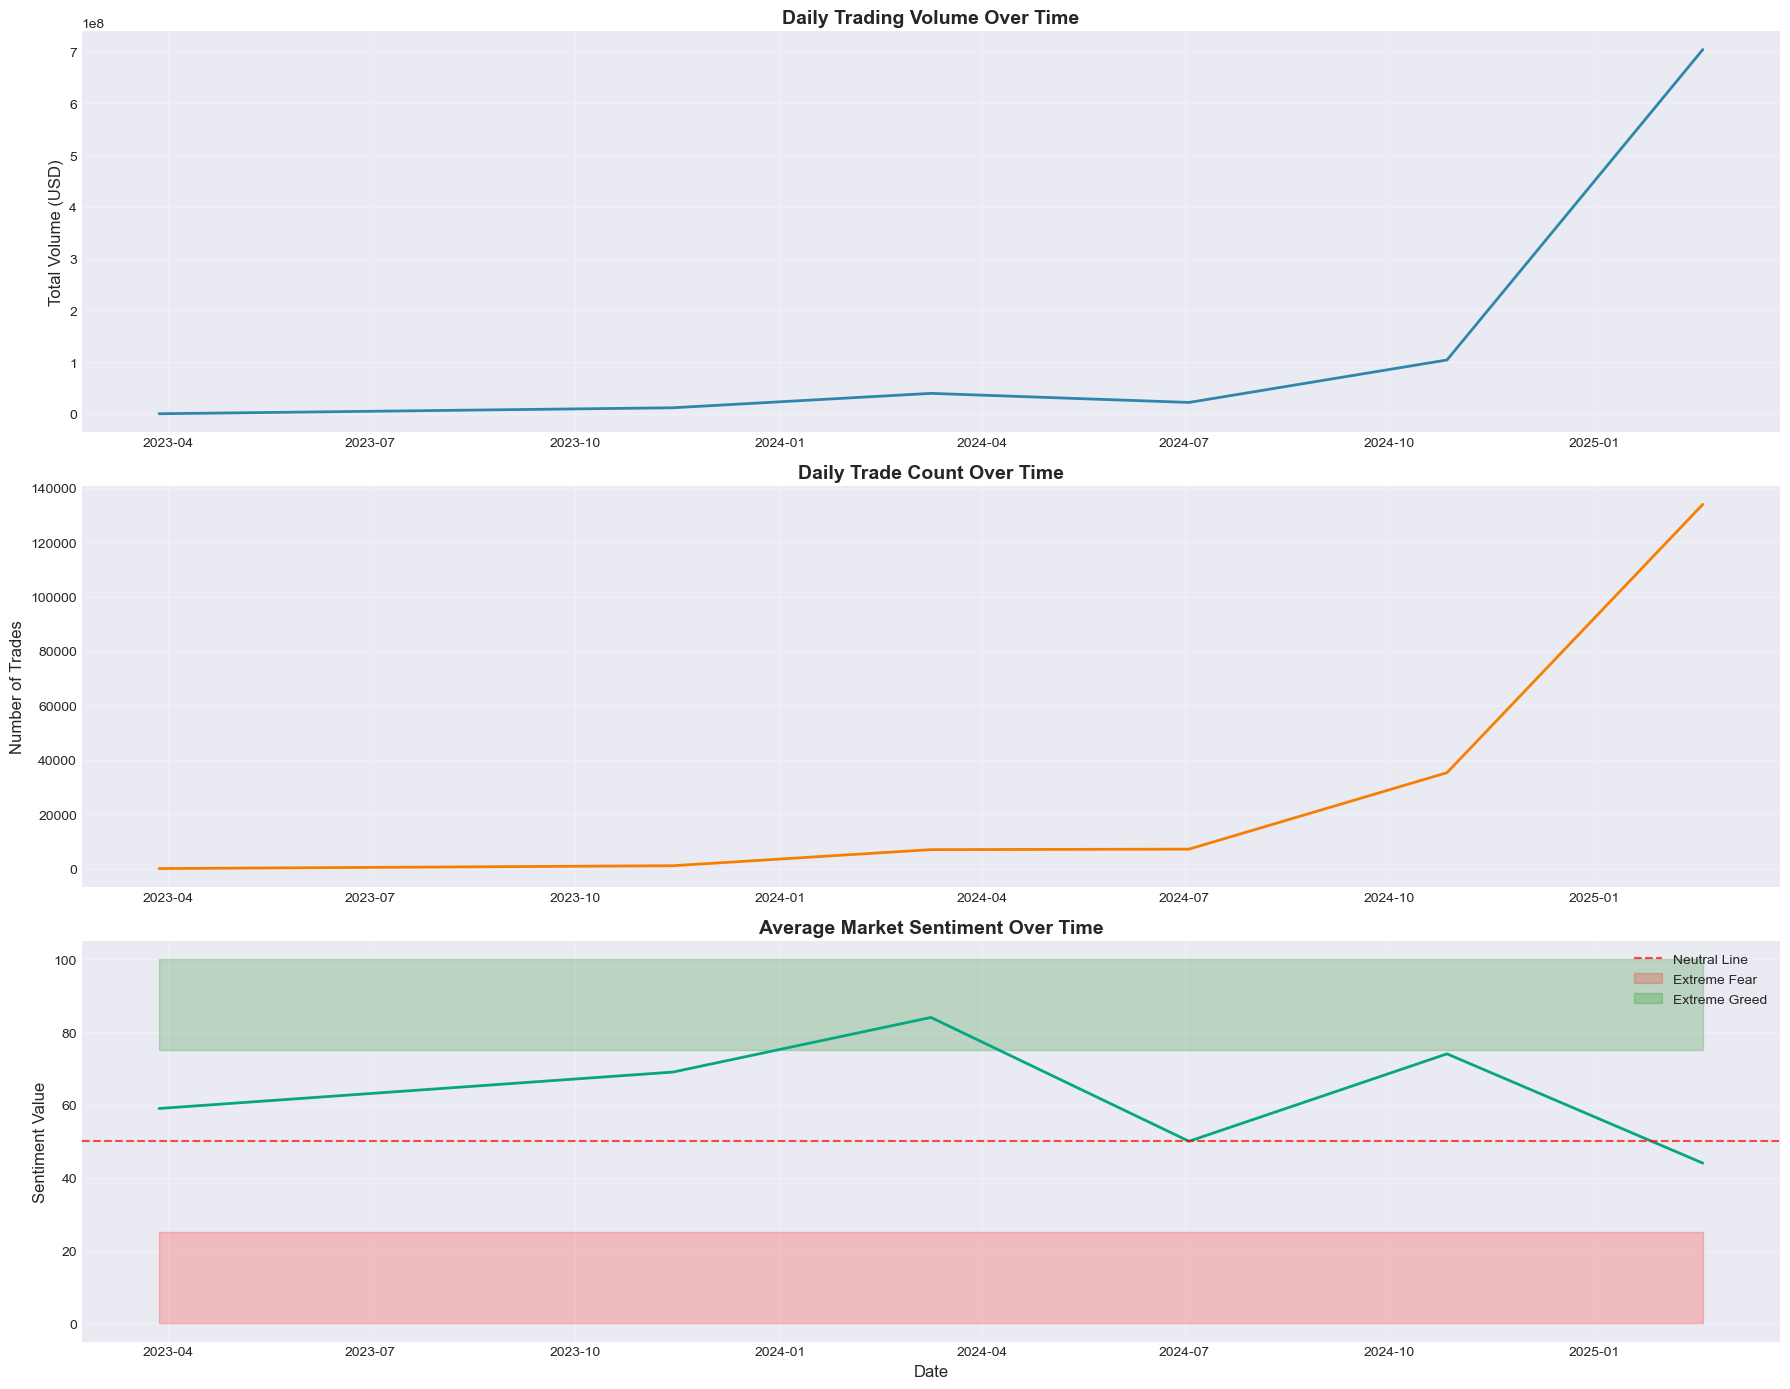

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

axes[0].plot(daily_trades['Date'], daily_trades['Total_Volume'], linewidth=2, color='#2E86AB')
axes[0].set_title('Daily Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Volume (USD)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_trades['Date'], daily_trades['Trade_Count'], linewidth=2, color='#F77F00')
axes[1].set_title('Daily Trade Count Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Trades', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily_trades['Date'], daily_trades['Avg_Sentiment'], linewidth=2, color='#06A77D')
axes[2].axhline(y=50, color='red', linestyle='--', label='Neutral Line', alpha=0.7)
axes[2].fill_between(daily_trades['Date'], 0, 25, alpha=0.2, color='red', label='Extreme Fear')
axes[2].fill_between(daily_trades['Date'], 75, 100, alpha=0.2, color='green', label='Extreme Greed')
axes[2].set_title('Average Market Sentiment Over Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Sentiment Value', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/time_series_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

daily_trades.to_csv('csv_files/daily_trading_patterns.csv', index=False)

### 4.7 Correlation Analysis

In [58]:
correlation_data = merged_data[['sentiment_value', 'Size USD', 'Closed PnL']].copy()

In [59]:
correlation_data = correlation_data.dropna()

In [60]:
correlation_matrix = correlation_data.corr()

In [61]:
correlation_matrix

,sentiment_value,Size USD,Closed PnL
sentiment_value,1.000000,-0.024110,0.011132
Size USD,-0.024110,1.000000,0.136853
Closed PnL,0.011132,0.136853,1.000000


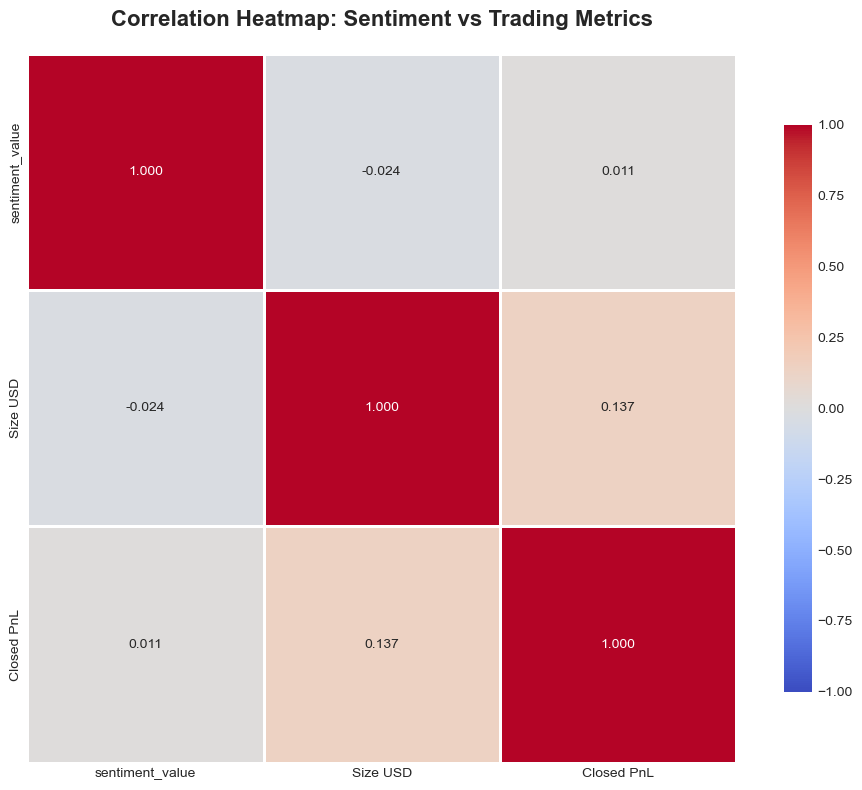

In [62]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap: Sentiment vs Trading Metrics', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
correlation_matrix.to_csv('csv_files/correlation_matrix.csv')

### 4.8 Distribution Analysis

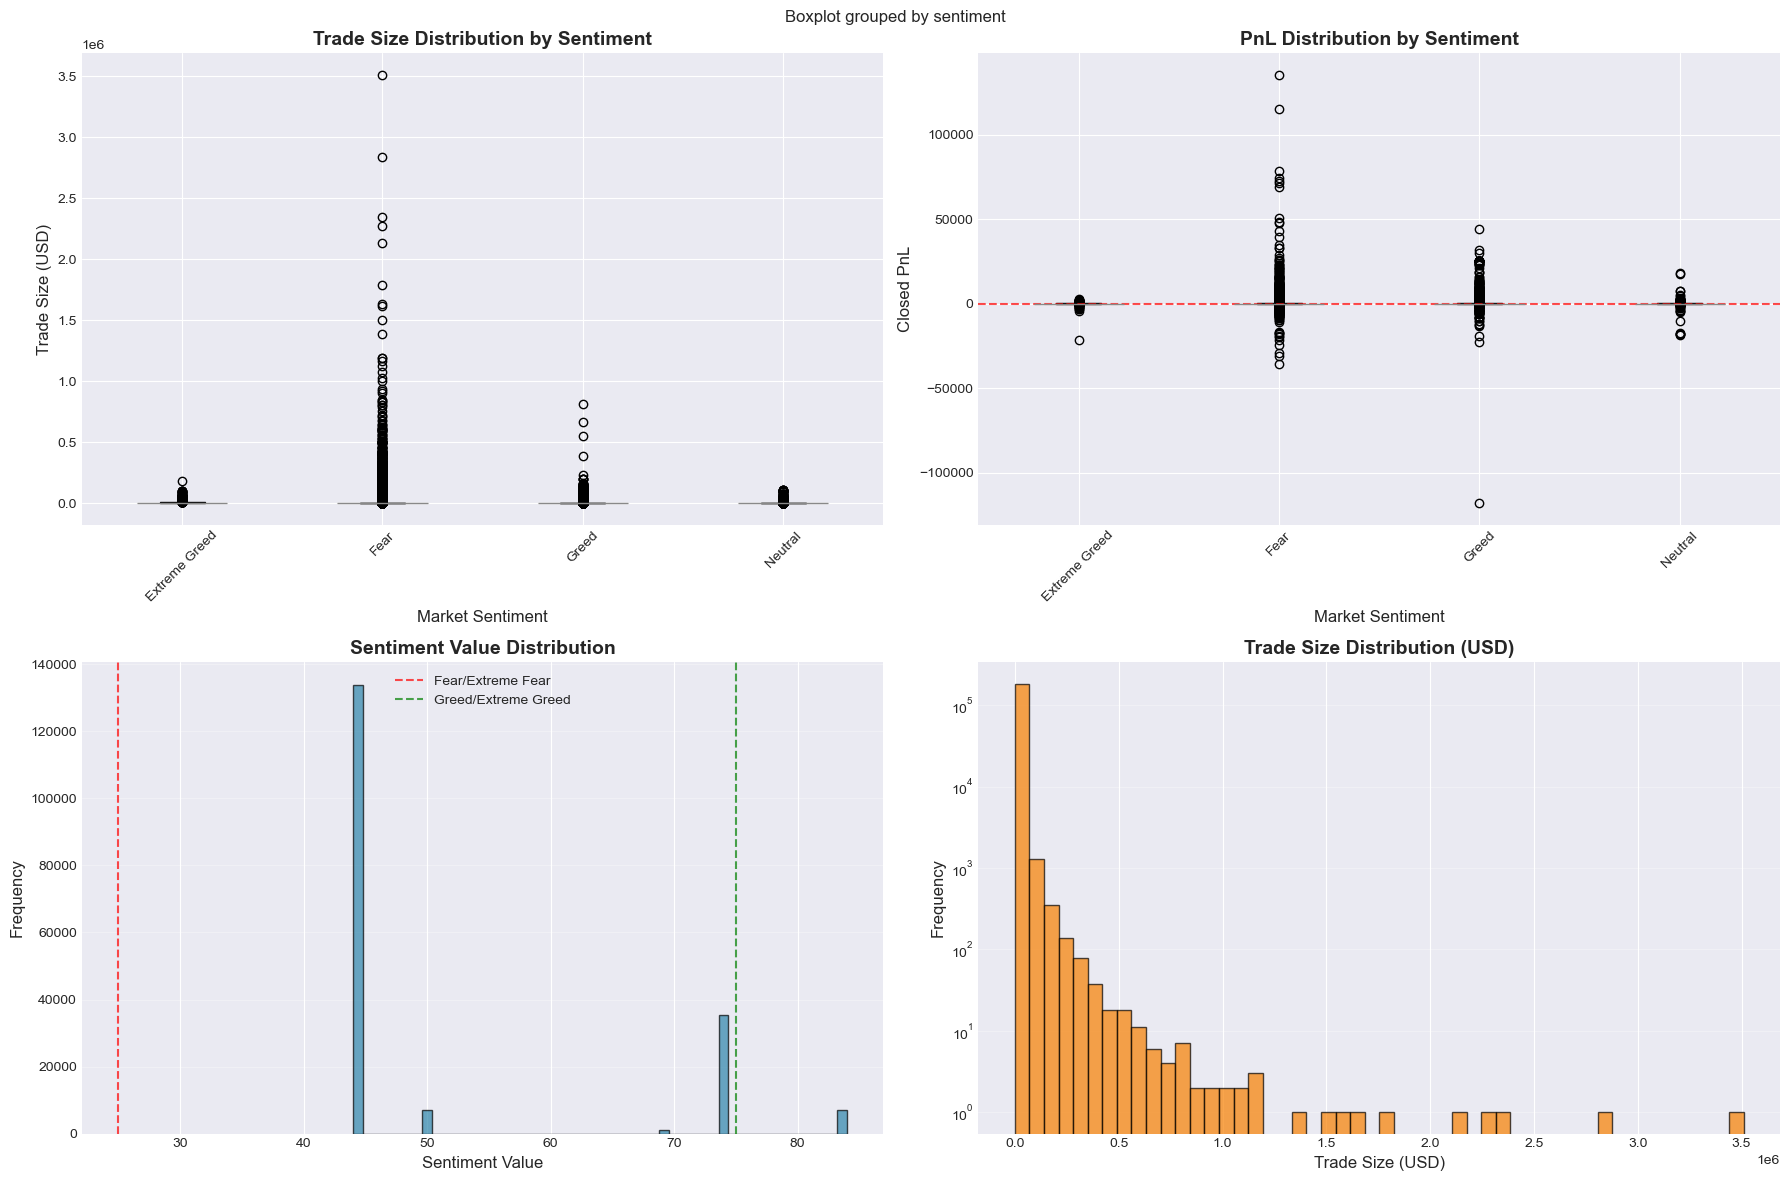

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

merged_data.boxplot(column='Size USD', by='sentiment', ax=axes[0, 0])
axes[0, 0].set_title('Trade Size Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Trade Size (USD)', fontsize=12)
axes[0, 0].set_xlabel('Market Sentiment', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
plt.sca(axes[0, 0])
plt.xticks(rotation=45)

pnl_trades.boxplot(column='Closed PnL', by='sentiment', ax=axes[0, 1])
axes[0, 1].set_title('PnL Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Closed PnL', fontsize=12)
axes[0, 1].set_xlabel('Market Sentiment', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)

axes[1, 0].hist(merged_data['sentiment_value'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=25, color='red', linestyle='--', label='Fear/Extreme Fear', alpha=0.7)
axes[1, 0].axvline(x=75, color='green', linestyle='--', label='Greed/Extreme Greed', alpha=0.7)
axes[1, 0].set_title('Sentiment Value Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment Value', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

merged_data['Size USD'].hist(bins=50, ax=axes[1, 1], color='#F77F00', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Trade Size Distribution (USD)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Trade Size (USD)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_yscale('log')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Key Insights and Findings

In [67]:
insights = []

total_trades_by_sentiment = merged_data['sentiment'].value_counts()
insights.append(f"1. Most Active Sentiment Period: {total_trades_by_sentiment.idxmax()} with {total_trades_by_sentiment.max():,} trades")

avg_pnl_by_sentiment = pnl_trades.groupby('sentiment')['Closed PnL'].mean().sort_values(ascending=False)
insights.append(f"2. Most Profitable Sentiment: {avg_pnl_by_sentiment.idxmax()} (Avg PnL: ${avg_pnl_by_sentiment.max():.2f})")
insights.append(f"3. Least Profitable Sentiment: {avg_pnl_by_sentiment.idxmin()} (Avg PnL: ${avg_pnl_by_sentiment.min():.2f})")

profit_ratio_by_sentiment = pnl_by_sentiment['profit_ratio'].sort_values(ascending=False)
insights.append(f"4. Highest Win Rate: {profit_ratio_by_sentiment.idxmax()} ({profit_ratio_by_sentiment.max():.2f}% profitable trades)")

volume_by_sentiment_total = merged_data.groupby('sentiment')['Size USD'].sum().sort_values(ascending=False)
insights.append(f"5. Highest Trading Volume: {volume_by_sentiment_total.idxmax()} (${volume_by_sentiment_total.max():,.2f})")

buy_sell_ratio = merged_data.groupby('sentiment')['Side'].value_counts(normalize=True).unstack(fill_value=0)
if 'BUY' in buy_sell_ratio.columns:
    max_buy_sentiment = buy_sell_ratio['BUY'].idxmax()
    insights.append(f"6. Most Buy-Heavy Sentiment: {max_buy_sentiment} ({buy_sell_ratio.loc[max_buy_sentiment, 'BUY']*100:.1f}% buys)")

sentiment_corr = correlation_data.corr()['sentiment_value'].drop('sentiment_value')
insights.append(f"7. Sentiment-Volume Correlation: {sentiment_corr['Size USD']:.3f}")
insights.append(f"8. Sentiment-PnL Correlation: {sentiment_corr['Closed PnL']:.3f}")

unique_traders = merged_data['Account'].nunique()
unique_coins = merged_data['Coin'].nunique()
insights.append(f"9. Total Unique Traders: {unique_traders:,}")
insights.append(f"10. Total Unique Coins Traded: {unique_coins}")


print(" "*25 + "KEY INSIGHTS & FINDINGS")
print()
for insight in insights:
    print(insight)

with open('csv_files/key_insights.txt', 'w') as f:
    f.write("\n".join(insights))

                         KEY INSIGHTS & FINDINGS

1. Most Active Sentiment Period: Fear with 133,871 trades
2. Most Profitable Sentiment: Greed (Avg PnL: $167.21)
3. Least Profitable Sentiment: Extreme Greed (Avg PnL: $40.85)
4. Highest Win Rate: Fear (86.12% profitable trades)
5. Highest Trading Volume: Fear ($704,158,492.98)
6. Most Buy-Heavy Sentiment: Fear (49.4% buys)
7. Sentiment-Volume Correlation: -0.024
8. Sentiment-PnL Correlation: 0.011
9. Total Unique Traders: 32
10. Total Unique Coins Traded: 239


## 6. Strategic Trading Recommendations

In [68]:
recommendations = [
    "STRATEGIC TRADING RECOMMENDATIONS:",
    "",
    "1. SENTIMENT-BASED ENTRY/EXIT:",
    "   - Monitor sentiment shifts from extreme fear to fear as potential buy signals",
    "   - Consider profit-taking when sentiment shifts from greed to extreme greed",
    "",
    "2. VOLUME ANALYSIS:",
    "   - High volume during fear periods may indicate capitulation and reversal opportunities",
    "   - Declining volume during greed phases could signal weakening momentum",
    "",
    "3. RISK MANAGEMENT:",
    "   - Reduce position sizes during extreme sentiment periods (both fear and greed)",
    "   - Neutral sentiment periods show more consistent trading patterns",
    "",
    "4. CONTRARIAN OPPORTUNITIES:",
    "   - Extreme fear often precedes strong rebounds - look for accumulation signals",
    "   - Extreme greed periods require caution and tight stop-losses",
    "",
    "5. DIVERSIFICATION:",
    "   - Different coins perform differently across sentiment phases",
    "   - Analyze top coins per sentiment for optimal asset allocation"
]

print()
for rec in recommendations:
    print(rec)
print()

with open('csv_files/trading_recommendations.txt', 'w') as f:
    f.write("\n".join(recommendations))


STRATEGIC TRADING RECOMMENDATIONS:

1. SENTIMENT-BASED ENTRY/EXIT:
   - Monitor sentiment shifts from extreme fear to fear as potential buy signals
   - Consider profit-taking when sentiment shifts from greed to extreme greed

2. VOLUME ANALYSIS:
   - High volume during fear periods may indicate capitulation and reversal opportunities
   - Declining volume during greed phases could signal weakening momentum

3. RISK MANAGEMENT:
   - Reduce position sizes during extreme sentiment periods (both fear and greed)
   - Neutral sentiment periods show more consistent trading patterns

4. CONTRARIAN OPPORTUNITIES:
   - Extreme fear often precedes strong rebounds - look for accumulation signals
   - Extreme greed periods require caution and tight stop-losses

5. DIVERSIFICATION:
   - Different coins perform differently across sentiment phases
   - Analyze top coins per sentiment for optimal asset allocation



## 7. Summary Statistics Export

In [69]:
summary_stats = {
    'Total Trades Analyzed': len(merged_data),
    'Date Range': f"{merged_data['Date'].min()} to {merged_data['Date'].max()}",
    'Unique Traders': merged_data['Account'].nunique(),
    'Unique Coins': merged_data['Coin'].nunique(),
    'Total Volume (USD)': f"${merged_data['Size USD'].sum():,.2f}",
    'Average Trade Size': f"${merged_data['Size USD'].mean():.2f}",
    'Total Closed PnL': f"${pnl_trades['Closed PnL'].sum():.2f}",
    'Overall Win Rate': f"{(pnl_trades['Closed PnL'] > 0).sum() / len(pnl_trades) * 100:.2f}%"
}

In [70]:
summary_df = pd.DataFrame(list(summary_stats.items()), columns=['Metric', 'Value'])
summary_df

,Metric,Value
0,Total Trades Analyzed,184263
1,Date Range,2023-03-28 00:00:00 to 2025-02-19 00:00:00
2,Unique Traders,32
3,Unique Coins,239
4,Total Volume (USD),"$880,912,169.43"
5,Average Trade Size,$4780.73
6,Total Closed PnL,$10225249.60
7,Overall Win Rate,85.35%


In [71]:
summary_df.to_csv('csv_files/summary_statistics.csv', index=False)